# Wavefield · Visco-acoustic, nearly constant-Q (Zhu & Harris 2014)

`ViscoAcoustic` is the attenuating counterpart of `Acoustic`: the same
second-order pressure field and the same CPML absorbing boundaries, with
nearly constant-Q attenuation added as two **decoupled** terms that switch
independently:

- **`phase_shift`** — velocity dispersion. Higher frequencies travel slightly
  faster, so the wavefront *moves*. Non-dissipative: it costs no energy.
  Numerically it is exactly an effective velocity
  $v_p\sqrt{1-c}$ with $c = (1-\sqrt{Q^2+1})/Q^2$, folded into the CPML step.
- **`amplitude_damping`** — attenuation proper. The dissipative term removes
  energy through a $|k|$ operator on $\partial u/\partial t$ (one FFT per
  step), absorbing high frequencies first: the medium acts as a
  distance-dependent low-pass. It *weakens* the front without moving it.

Three model parameters: `vp`, `Q`, and the reference angular frequency
`omega`. Both switches off reduces **bit-exactly** to `Acoustic`.

## 1. Parameters

In [1]:
import warnings
import numpy as np
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', message='Torchinductor does not support.*')

from sweep.equations import ViscoAcoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

shape = (300, 400)             # 2.4 km x 3.2 km at 8 m spacing
dh    = 8.0
dt    = 1.0e-3
nt    = 800                    # 0.8 s: the farthest receiver (1.47 km) arrives at 0.69 s
abcn  = 40
freq, delay = 12.0, 0.10
vp_val, Q_val = 2500.0, 30.0
omega_val = 2.0 * np.pi * freq  # reference frequency of the constant-Q model
snapshot_times = (150, 300, 470)   # last front: 0.37 s x 2.5 km/s = 925 m < 1.2 km half-height

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

ppw = vp_val / (2.5 * freq) / dh
cfl = vp_val * dt / dh
print(f'ppw at fmax = {ppw:.1f}   CFL = {cfl:.3f}')
assert ppw >= 5.0 and cfl <= 0.5

full = lambda v: torch.full(shape, float(v), dtype=torch.float32, device=device)
models = [full(vp_val), full(Q_val), full(omega_val)]

src_iz, src_ix = shape[0] // 2, shape[1] // 2
sources = np.array([[src_ix, src_iz]], dtype=np.int64)
# receiver line at the source depth, right of the source: offsets for section 3
rx = np.arange(src_ix + 25, shape[1] - 12, 5, dtype=np.int64)
receivers = np.stack([rx, np.full_like(rx, src_iz)], -1)[None]
offsets = (rx - src_ix) * dh

t = np.arange(nt, dtype=np.float32) * dt - delay
wavelet = torch.tensor(ricker(t, f=freq).astype(np.float32), device=device)

device: cuda
ppw at fmax = 10.4   CFL = 0.312


## 2. The two attenuation switches

Same medium, same source — only the switches differ. Because the medium is
uniform the wavefront is a circle, so one snapshot can carry all four runs:
each quadrant comes from a different combination, and every seam flips
exactly one switch. The traces underneath make it quantitative:
`amplitude_damping` lowers the arrival, `phase_shift` moves it earlier
(the effective velocity at $Q=30$ is $\sim1.6\%$ above `vp`).

In [2]:
COMBOS = [((False, False), 'both off (= acoustic)'),
          ((True,  False), 'phase shift only'),
          ((False, True),  'amplitude damping only'),
          ((True,  True),  'both on (visco-acoustic)')]

runs = {}
for (ps, ad), label in COMBOS:
    eq = ViscoAcoustic(device=device, phase_shift=ps, amplitude_damping=ad)
    solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, nt=nt, abcn=abcn,
                       source_type=['h1'], receiver_type=['h1'],
                       impl='eager', use_ckpt=False)
    with torch.no_grad():
        rec, snaps = solver(wavelet, sources, receivers, models=models,
                            return_wavefield=True, snapshot_times=snapshot_times)
    # record comes back (B, nt, nrec, nfields); keep (nrec, nt)
    runs[(ps, ad)] = (label, rec[0, :, :, 0].T.cpu().numpy(),
                      snaps.cpu().numpy(), solver.pad)
    print(f'{label:28s} max|p| at t={snapshot_times[-1]*dt:.2f}s : '
          f'{snaps[-1, 0, 0, 0].abs().max().item():.3e}')

both off (= acoustic)        max|p| at t=0.47s : 3.782e-01


phase shift only             max|p| at t=0.47s : 3.664e-01


amplitude damping only       max|p| at t=0.47s : 2.390e-01


both on (visco-acoustic)     max|p| at t=0.47s : 2.331e-01


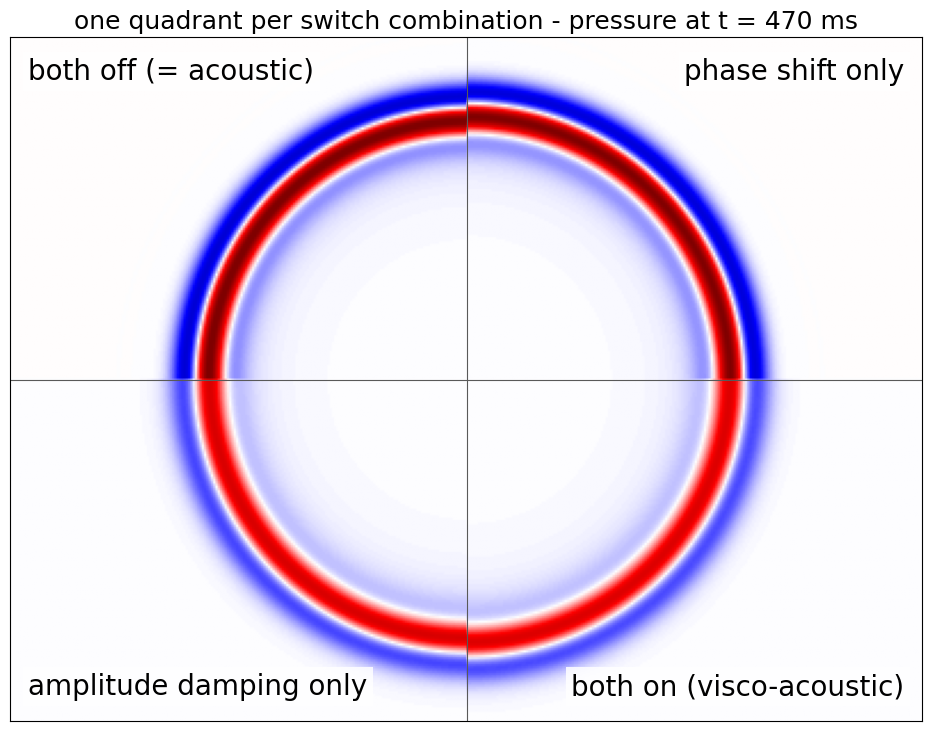

In [3]:
# The medium is uniform, so the wavefront is radially symmetric - stitch ONE
# image from a quadrant of each run.  Every seam separates two combos that
# differ by exactly one switch: the vertical seam flips phase_shift, the
# horizontal seam flips amplitude_damping.
_, _, snaps_ref, pad = runs[(False, False)]
z_lo, z_hi, x_lo, x_hi = pad
crop = lambda s: s[0, 0, 0, z_lo:s.shape[-2] - z_hi, x_lo:s.shape[-1] - x_hi]
fields = {key: crop(runs[key][2][-1]) for key, _ in COMBOS}

Z, X = np.ogrid[:shape[0], :shape[1]]
top, left = Z < src_iz, X < src_ix
masks = [top & left, top & ~left, ~top & left, ~top & ~left]
composite = np.empty(shape, np.float32)
for (key, _), m in zip(COMBOS, masks):
    composite[m] = fields[key][m]

clip = np.percentile(np.abs(fields[(False, False)]), 99)
fig, ax = plt.subplots(figsize=(9.5, 7.2), constrained_layout=True)
ax.imshow(composite, cmap='seismic', vmin=-clip, vmax=clip, aspect='equal')
ax.axvline(src_ix, color='0.35', lw=0.8); ax.axhline(src_iz, color='0.35', lw=0.8)
corners = [(0.02, 0.97, 'left', 'top'), (0.98, 0.97, 'right', 'top'),
           (0.02, 0.03, 'left', 'bottom'), (0.98, 0.03, 'right', 'bottom')]
for ((_, label), (cx, cy, ha, va)) in zip(COMBOS, corners):
    ax.text(cx, cy, label, transform=ax.transAxes, ha=ha, va=va, fontsize=20,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f'one quadrant per switch combination - pressure at '
             f't = {snapshot_times[-1] * dt * 1e3:.0f} ms', fontsize=18)
plt.show()

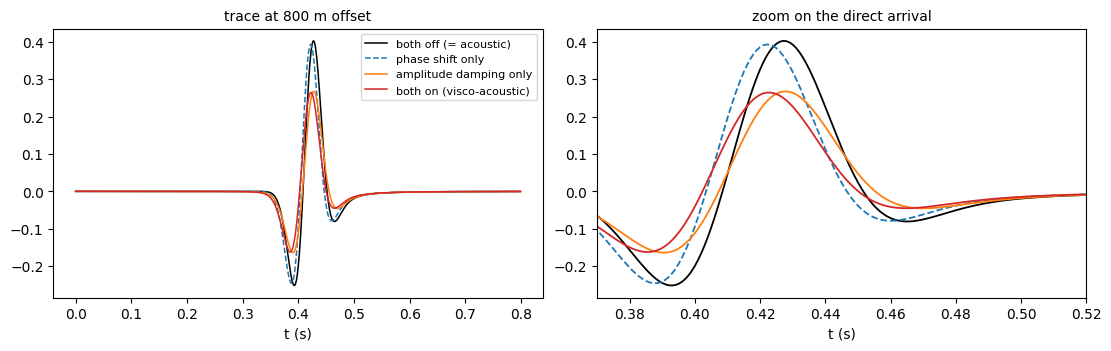

In [4]:
r_show = np.argmin(np.abs(offsets - 800.0))    # a receiver ~0.8 km out
t_axis = np.arange(nt) * dt
t_arr = delay + offsets[r_show] / vp_val

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True)
for (ps, ad), style in zip([c for c, _ in COMBOS], ['k-', 'C0--', 'C1-', 'C3-']):
    label, rec, _, _ = runs[(ps, ad)]
    axes[0].plot(t_axis, rec[r_show], style, lw=1.1, label=label)
    axes[1].plot(t_axis, rec[r_show], style, lw=1.3)
axes[0].legend(fontsize=8); axes[0].set_xlabel('t (s)')
axes[0].set_title(f'trace at {offsets[r_show]:.0f} m offset', fontsize=10)
axes[1].set_xlim(t_arr - 0.05, t_arr + 0.10); axes[1].set_xlabel('t (s)')
axes[1].set_title('zoom on the direct arrival', fontsize=10)
plt.show()

## 3. Constant-Q decay with offset

Constant-Q theory says the direct wave loses
$\exp\!\left(-\pi f\, r / (Q\, v_p)\right)$ to attenuation over a distance
$r$. Dividing each attenuating run by the acoustic reference cancels the
geometrical spreading and the source spectrum, so the ratio of peak
amplitudes should fall on that exponential. The dots use the peak of each
trace; the dashed lines evaluate the theory at the dominant frequency.
(A broadband wavelet downshifts as it attenuates, so the measured decay sits
slightly above the single-frequency prediction — first-order agreement is
what the decoupled formulation promises.)

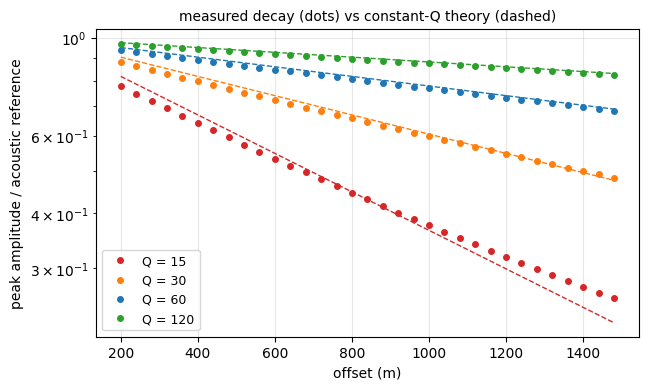

In [5]:
Q_SWEEP = [15.0, 30.0, 60.0, 120.0]
_, rec_ref, _, _ = runs[(False, False)]
peak_ref = np.abs(rec_ref).max(axis=-1)

fig, ax = plt.subplots(figsize=(7, 4))
for q, color in zip(Q_SWEEP, ['C3', 'C1', 'C0', 'C2']):
    eq = ViscoAcoustic(device=device)   # both terms on
    solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, nt=nt, abcn=abcn,
                       source_type=['h1'], receiver_type=['h1'],
                       impl='eager', use_ckpt=False)
    with torch.no_grad():
        rec = solver(wavelet, sources, receivers,
                     models=[full(vp_val), full(q), full(omega_val)])
    ratio = np.abs(rec[0, :, :, 0].T.cpu().numpy()).max(axis=-1) / peak_ref
    ax.semilogy(offsets, ratio, 'o', ms=4, color=color, label=f'Q = {q:.0f}')
    ax.semilogy(offsets, np.exp(-np.pi * freq * offsets / (q * vp_val)),
                '--', lw=1.0, color=color)
ax.set_xlabel('offset (m)'); ax.set_ylabel('peak amplitude / acoustic reference')
ax.set_title('measured decay (dots) vs constant-Q theory (dashed)', fontsize=10)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.show()

## 4. Per-edge free surface

Like `Acoustic` and `Elastic`, the visco-acoustic equation accepts a free
surface on **any subset of the four faces** — a bool (top only), a list of
face names, or a 4-mask. Active faces are pressure-release ($p=0$); the
remaining faces keep their PML.

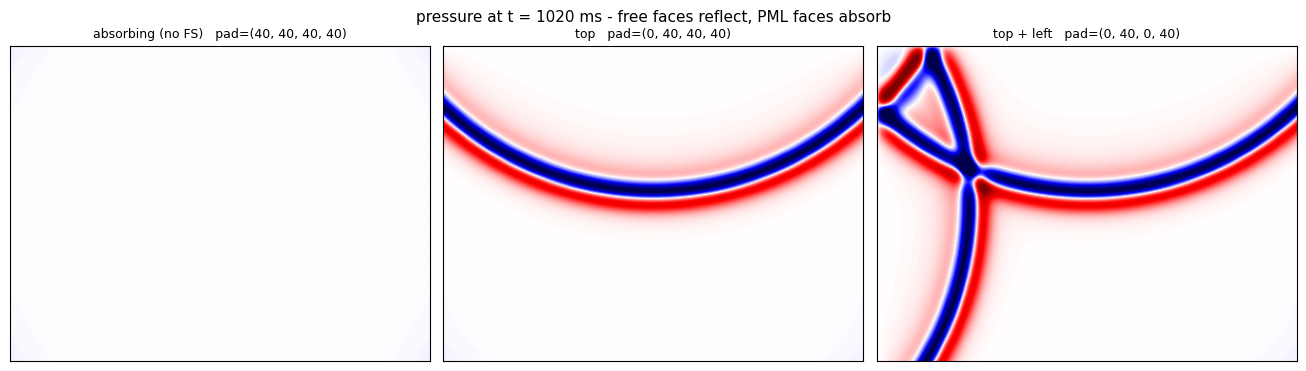

In [6]:
# Give this section more time: the direct wave must REACH a face and come
# back for the comparison to show anything.  With the source at the centre
# the top face is 1.2 km away (hit at 0.58 s) and the left face 1.6 km
# (hit at 0.74 s); by t = 1.02 s both reflections are well inside the box.
nt_fs = 1050
t_fs = np.arange(nt_fs, dtype=np.float32) * dt - delay
wavelet_fs = torch.tensor(ricker(t_fs, f=freq).astype(np.float32), device=device)
snap_fs = 1020

fs_configs = [(False, 'absorbing (no FS)'), (['top'], 'top'), (['top', 'left'], 'top + left')]
fields_fs = []
for fs, label in fs_configs:
    eq = ViscoAcoustic(device=device)
    solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, nt=nt_fs, abcn=abcn,
                       source_type=['h1'], receiver_type=['h1'],
                       free_surface=fs, impl='eager', use_ckpt=False)
    with torch.no_grad():
        _, snaps = solver(wavelet_fs, sources, receivers, models=models,
                          return_wavefield=True, snapshot_times=[snap_fs])
    z_lo, z_hi, x_lo, x_hi = solver.pad
    s = snaps[-1, 0, 0, 0].cpu().numpy()
    fields_fs.append((label, solver.pad,
                      s[z_lo:s.shape[-2] - z_hi, x_lo:s.shape[-1] - x_hi]))

clip_fs = np.percentile(np.abs(fields_fs[-1][2]), 99)   # scale from top+left
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)
for ax, (label, pad, field) in zip(axes, fields_fs):
    ax.imshow(field, cmap='seismic', vmin=-clip_fs, vmax=clip_fs, aspect='equal')
    ax.set_title(f'{label}   pad={pad}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'pressure at t = {snap_fs * dt * 1e3:.0f} ms - '
             'free faces reflect, PML faces absorb', fontsize=11)
plt.show()

## 5. eager vs `impl='c'` (CUDA)

The compiled backend reuses the acoustic CPML CUDA kernels with the
dispersion folded into an effective velocity, and adds the spectral damping
term (cuFFT) with a hand-derived exact adjoint. Records and all gradients
match the eager autograd reference; the checkpointed backward matches full
storage to float precision.

In [7]:
if device.type == 'cuda':
    rel = lambda a, b: (torch.linalg.vector_norm(a - b) /
                        torch.linalg.vector_norm(b)).item()
    cos = lambda a, b: torch.nn.functional.cosine_similarity(
        a.ravel(), b.ravel(), dim=0).item()
    grads = {}
    for impl in ('eager', 'c'):
        eq = ViscoAcoustic(device=device)
        kw = {'boundary_saving_config': {'enabled': False}} if impl == 'c' else {}
        solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, nt=nt, abcn=abcn,
                           source_type=['h1'], receiver_type=['h1'],
                           free_surface=['top'], impl=impl, use_ckpt=False, **kw)
        m = [full(vp_val).requires_grad_(True), full(Q_val).requires_grad_(True),
             full(omega_val)]
        rec = solver(wavelet, sources, receivers, models=m)
        (rec ** 2).sum().backward()
        grads[impl] = (rec.detach(), m[0].grad.clone(), m[1].grad.clone())
    r_e, gv_e, gq_e = grads['eager']; r_c, gv_c, gq_c = grads['c']
    print(f'record  rel_l2 = {rel(r_c, r_e):.2e}')
    print(f'vp grad cos = {cos(gv_c, gv_e):.6f}   rel_l2 = {rel(gv_c, gv_e):.2e}')
    print(f'Q  grad cos = {cos(gq_c, gq_e):.6f}   rel_l2 = {rel(gq_c, gq_e):.2e}')
else:
    print('CUDA not available - impl=\'c\' comparison skipped')

record  rel_l2 = 1.28e-05
vp grad cos = 1.000000   rel_l2 = 3.18e-07
Q  grad cos = 1.000000   rel_l2 = 3.67e-07


## Notes

- **Both switches off is `Acoustic`, bit for bit** — on both backends (the
  test suite asserts `torch.equal` on records and gradients). Use the
  switches to isolate which physical effect matters for your data.
- **Gradients.** Eager autograd everywhere; `impl='c'` implements forward,
  `full` and checkpointed backwards with a hand-derived adjoint (`vp`, `Q`,
  wavelet). **Boundary saving is refused**: the dissipative global-FFT term
  makes reverse-time reconstruction from boundary strips ill-posed, so the
  compiled default falls back to full storage and an explicit boundary
  request raises.
- **`omega` has no gradient** by construction: under the constant-Q
  parametrisation the damping coefficient is independent of the reference
  frequency, so `g_omega = 0` is correct, not a bug.
- **Backends.** Eager runs on torch (CPU/GPU) and jax; `impl='c'` is
  CUDA-only, 2-D only.